In [32]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
root = "/home/kinichen/scratch/data/pydfc_validator/similarity_assessments_20260604"

with open(f"{root}/similarity.pkl", "rb") as f:
    similarity = pickle.load(f)
    
print(similarity.keys())    # layer 1 of hierarchy is datasets, then subjects, sessions, runs, tasks, etc. (pydFC objects)

dict_keys(['ds003465'])


In [33]:
# Example of accessing similarity matrix for a specific dataset, subject, session, run, and task

dataset_id = "ds003465"
subject_id = "sub-f1027ao"
session_id = "ses-wave1bas"
run_id = "run-2"
task_id = "task-Stroop"

sim_ex = similarity[dataset_id][subject_id][session_id][run_id][task_id]

########### Similarity matrix #############
matrix_ex = sim_ex["matrix"]["all"]["spearman"]  # similarity matrix for all methods
print(matrix_ex.shape)
display(matrix_ex)

(1, 33, 33)


array([[[0.        , 0.3161627 , 0.34533259, ..., 0.31228163,
         0.41638892, 0.21287086],
        [0.3161627 , 0.        , 0.67303674, ..., 0.92539089,
         0.34746954, 0.24018584],
        [0.34533259, 0.67303674, 0.        , ..., 0.71115469,
         0.34024813, 0.28499195],
        ...,
        [0.31228163, 0.92539089, 0.71115469, ..., 0.        ,
         0.3532287 , 0.2453657 ],
        [0.41638892, 0.34746954, 0.34024813, ..., 0.3532287 ,
         0.        , 0.13410536],
        [0.21287086, 0.24018584, 0.28499195, ..., 0.2453657 ,
         0.13410536, 0.        ]]], shape=(1, 33, 33))

In [ ]:
######## List of similarity measures used ###########
# Should be the same across all datasets, subjects, sessions, runs, tasks, etc.

# methods_num_ex = sim_ex["methods"]  # actual names provided from pydfc, so can ignore this
# print(methods_num_ex)  # list of method numbers (indices) used in the similarity assessment

measures = sim_ex["matrix"]["measure_lst"]
methods = [method.MEASURE_NAME for method in measures]  # extract method names from the pydfc dfc_methods objects
print(methods[:5])
print(len(methods))

['AdaptiveExponentialWindow', 'AgglomerativeStates', 'BayesianGaussianMixtureStates', 'BirchStates', 'CAP']
33


In [42]:
######### Helper functions to collect and aggregate similarity matrices based on filters 
# for various levels (dataset, subject, session, run, task) #########

def collect_similarity_matrices(
    similarity: dict,
    dataset_id=None,
    subject_id=None,
    session_id=None,
    run_id=None,
    task_id=None,
    similarity_key="all",
    metric="spearman",
):
    """
    Collect all similarity matrices matching the specified filters. If a filter is None, 
    it matches all values for that level and aggregates over/across it.

    Returns:
        matrices: list of np.ndarray of shape (1, n_methods, n_methods)
    """

    matrices = []

    for ds, ds_data in similarity.items():

        if dataset_id is not None and ds != dataset_id:
            continue

        for sub, sub_data in ds_data.items():

            if subject_id is not None and sub != subject_id:
                continue

            for ses, ses_data in sub_data.items():

                if session_id is not None and ses != session_id:
                    continue

                for run, run_data in ses_data.items():

                    if run_id is not None and run != run_id:
                        continue

                    for task, task_data in run_data.items():

                        if task_id is not None and task != task_id:
                            continue

                        matrices.append(
                            task_data["matrix"][similarity_key][metric]
                        )

    return matrices




def aggregate_similarity_matrices(
    matrices,
    aggregation="mean"
):
    """
    Parameters
    ----------
    matrices : list of arrays
        Each array has shape (1, n_methods, n_methods)

    Returns
    -------
    aggregated_matrix : np.ndarray
        Shape (n_methods, n_methods)

    n_matrices : int
        Number of matrices contributing to the aggregation (sample size)
    """

    if len(matrices) == 0:
        raise ValueError("No matrices found.")

    arr = np.concatenate(matrices, axis=0)

    if aggregation == "mean":
        aggregated = np.mean(arr, axis=0)

    elif aggregation == "median":
        aggregated = np.median(arr, axis=0)

    elif aggregation == "std":
        aggregated = np.std(arr, axis=0)

    else:
        raise ValueError(
            f"Unknown aggregation: {aggregation}"
        )

    return aggregated, len(matrices)



def plot_similarity_heatmap(
    matrix,
    aggregation_size=None,
    method_names=methods,
    title="Similarity Heatmap",
    annot=False,
    figsize=(10, 8),
    cmap="viridis",
):
    plt.figure(figsize=figsize)

    sns.heatmap(
        matrix,
        annot=annot,
        xticklabels=method_names,
        yticklabels=method_names,
        cmap=cmap,
    )
    
    if aggregation_size is not None:
        title += f" (n={aggregation_size})"

    plt.title(title)

    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()

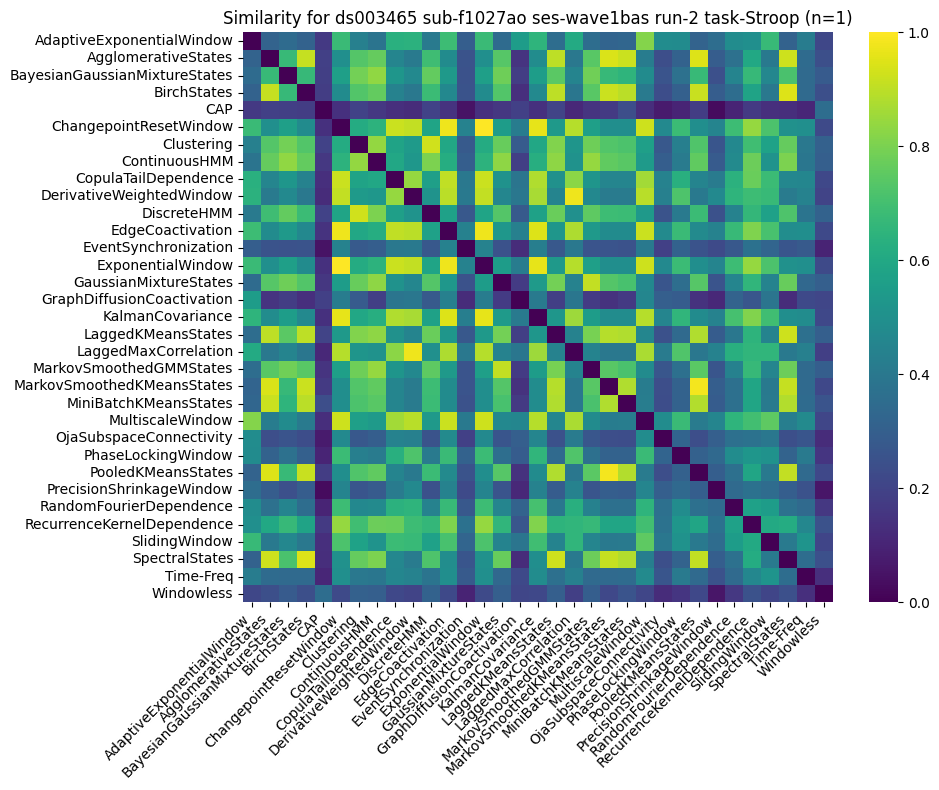

In [ ]:
### 1) Specific dataset, subject, session, run, task (no aggregation) ###

# Need matrix_ex[0] because matrix_ex is a list of matrices (one per similarity measure)
# plot_similarity_heatmap(matrix_ex[0], methods_ex, title=f"Similarity for {dataset_id} {subject_id} {session_id} {run_id} {task_id}")

# Same as
matrices = collect_similarity_matrices(
    similarity,
    dataset_id=dataset_id,
    subject_id=subject_id,
    session_id=session_id,
    run_id=run_id,
    task_id=task_id
)

aggregated, aggregation_size = aggregate_similarity_matrices(
    matrices,
    aggregation="mean"
)

plot_similarity_heatmap(
    aggregated,
    aggregation_size,
    title=f"Similarity for {dataset_id} {subject_id} {session_id} {run_id} {task_id}"
)

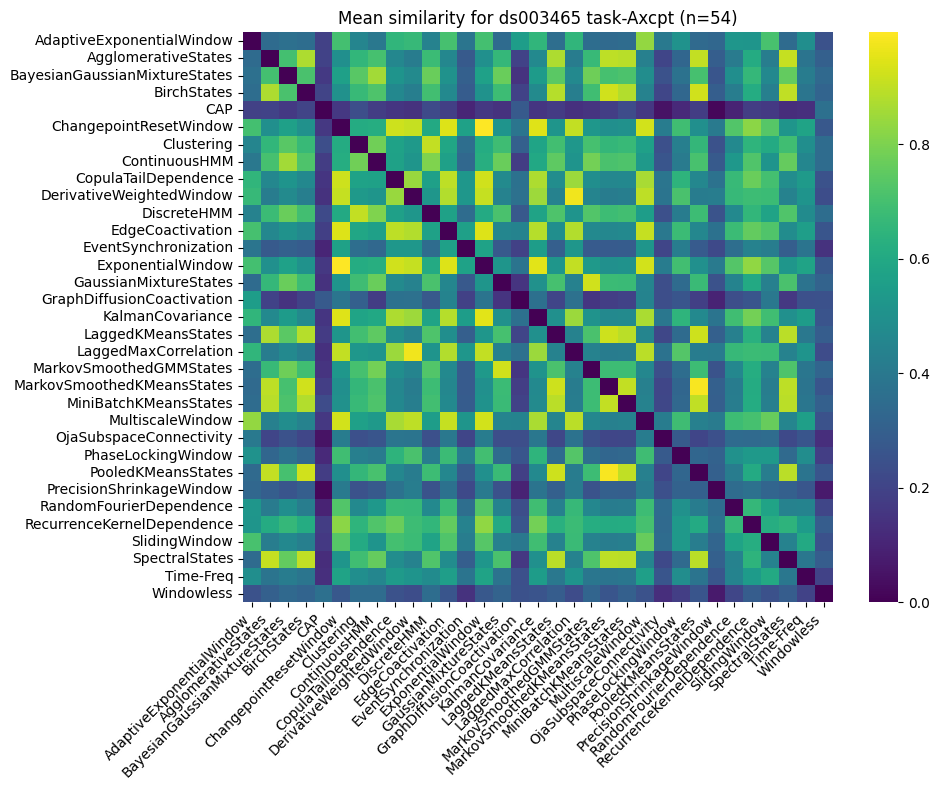

In [49]:
### 2.a) Average over all subjects, sessions, and runs ###

task_id = "task-Axcpt"

matrices = collect_similarity_matrices(
    similarity,
    dataset_id=dataset_id,
    task_id=task_id
)

aggregated, aggregation_size = aggregate_similarity_matrices(
    matrices,
    aggregation="mean"
)

plot_similarity_heatmap(
    aggregated,
    aggregation_size,
    title=f"Mean similarity for {dataset_id} {task_id}"
)

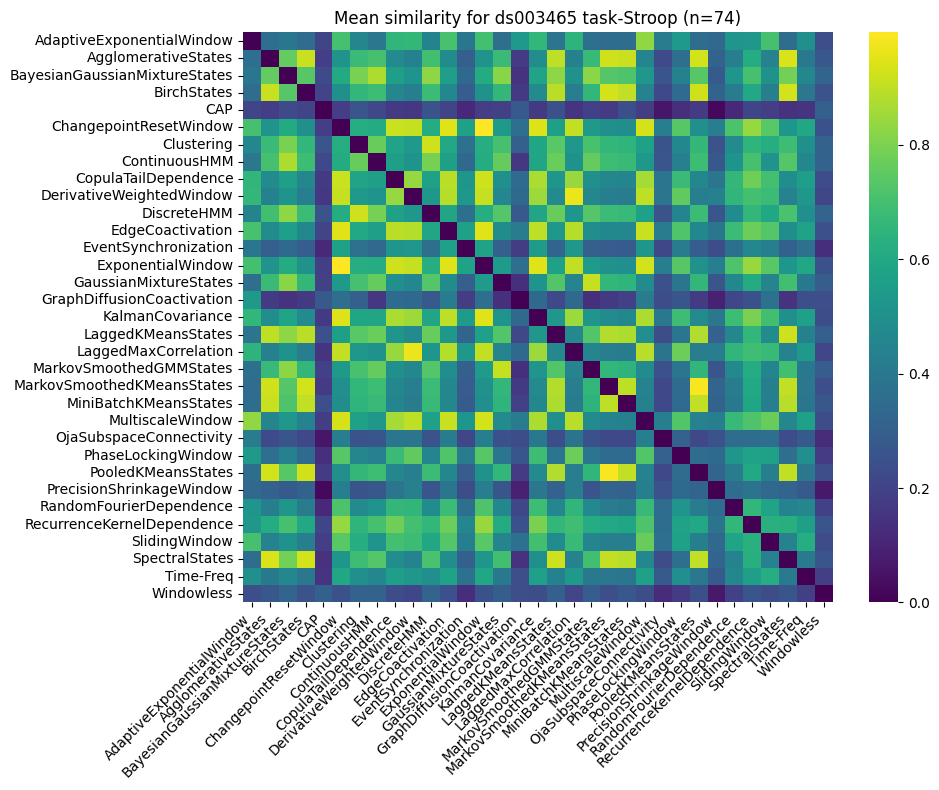

In [50]:
### 2.b) Compare tasks from 2.a) ###

task_id = "task-Stroop"

matrices = collect_similarity_matrices(
    similarity,
    dataset_id=dataset_id,
    task_id=task_id
)

aggregated, aggregation_size = aggregate_similarity_matrices(
    matrices,
    aggregation="mean"
)

plot_similarity_heatmap(
    aggregated,
    aggregation_size,
    title=f"Mean similarity for {dataset_id} {task_id}"
)

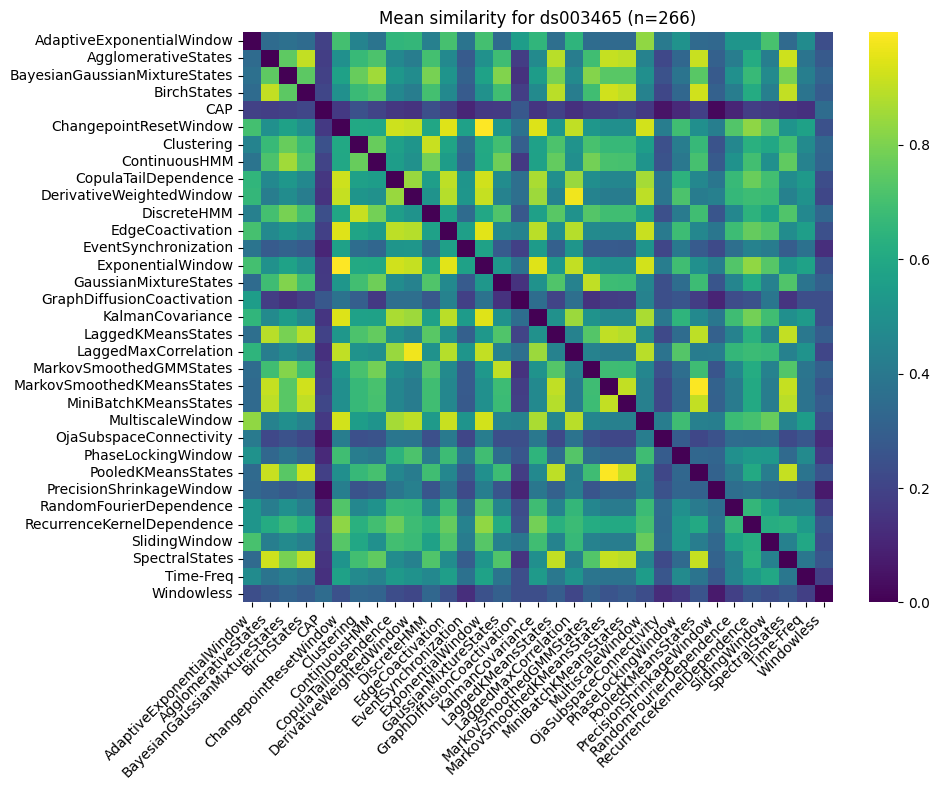

In [47]:
### 3.a) Average over everything for a specific dataset ###

matrices = collect_similarity_matrices(
    similarity,
    dataset_id=dataset_id
)

aggregated, aggregation_size = aggregate_similarity_matrices(
    matrices,
    aggregation="mean"
)

plot_similarity_heatmap(
    aggregated,
    aggregation_size,
    title=f"Mean similarity for {dataset_id}"
)

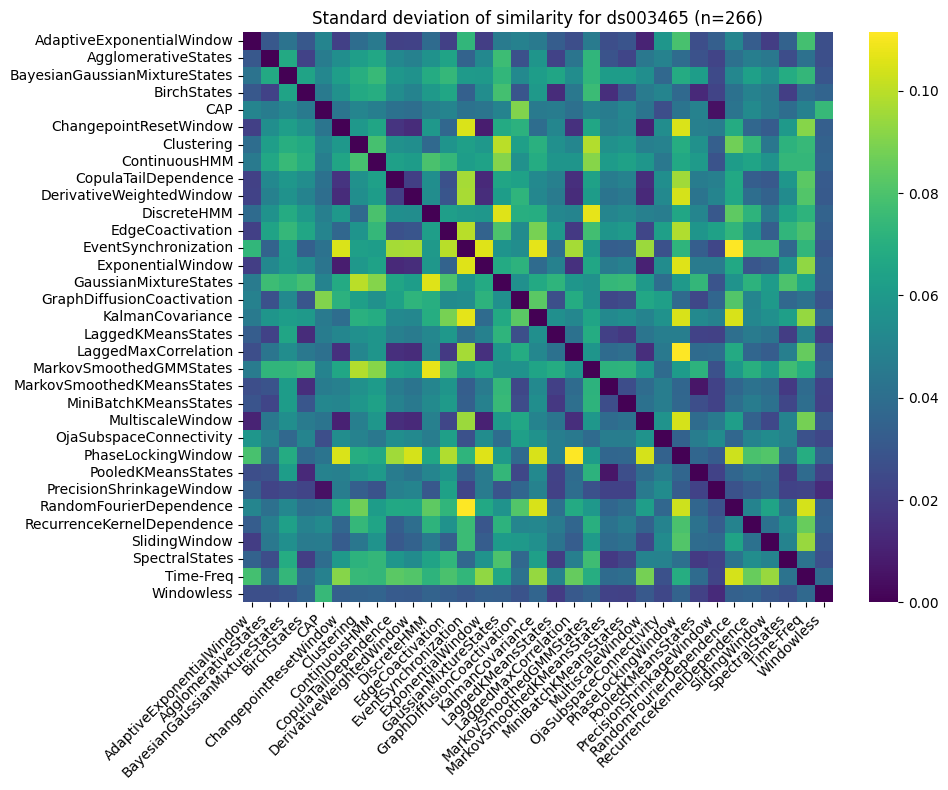

In [48]:
### 3.b) Standard deviation over everything for a specific dataset ###
# Measures which method pairs are more stable vs. more variable across filters

matrices = collect_similarity_matrices(
    similarity,
    dataset_id=dataset_id
)

aggregated, aggregation_size = aggregate_similarity_matrices(
    matrices,
    aggregation="std"
)

plot_similarity_heatmap(
    aggregated,
    aggregation_size,
    title=f"Standard deviation of similarity for {dataset_id}"
)